# Employee Reimbursement Prediction using Multiple Linear Regression

## Problem Statement

The New York City Controller's Office maintains a database of the salary and benefits paid to city employees since the financial year 2015. This is data representing the employee reimbursement report.
The objective of this project is to build a Multiple Linear Regression model to predict employee reimbursement values using income and benefits-related variables.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("Emp_reimb.csv")

In [3]:
df.shape

(49794, 12)

In [4]:
df.head()

,Year,Type_of_yr,Emp_ID,Income,Other_Income,Overtime,Total_Income,Health_Insurance,Retirement,Other_Benefits,Total_Benefits,Total_Reimbursement
0,2015,Financial,42865,92288.22,267.45,270.45,92826.12,12500.56,20703.20,7605.75,40809.51,133635.63
1,2015,Calendar,28253,1466.38,0.00,350.23,1816.61,442.03,3.00,141.59,586.62,2403.23
2,2018,Financial,30664,76536.95,10855.94,13586.72,100979.61,12464.61,18636.19,8011.41,39112.21,140091.82
3,2018,Financial,19482,45659.88,1625.37,3.00,47288.25,0.00,10084.20,3936.63,14020.83,61309.08
4,2017,Financial,7183,41832.00,0.00,6.00,41838.00,5908.52,7621.60,3254.50,16784.62,58622.62


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49794 entries, 0 to 49793
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 49794 non-null  int64  
 1   Type_of_yr           49794 non-null  object 
 2   Emp_ID               49794 non-null  int64  
 3   Income               49794 non-null  float64
 4   Other_Income         49794 non-null  float64
 5   Overtime             49794 non-null  float64
 6   Total_Income         49794 non-null  float64
 7   Health_Insurance     49794 non-null  float64
 8   Retirement           49794 non-null  float64
 9   Other_Benefits       49794 non-null  float64
 10  Total_Benefits       49794 non-null  float64
 11  Total_Reimbursement  49794 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 4.6+ MB


In [6]:
df.describe()

,Year,Emp_ID,Income,Other_Income,Overtime,Total_Income,Health_Insurance,Retirement,Other_Benefits,Total_Benefits,Total_Reimbursement
count,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000,49794.000000
mean,2016.542013,26960.672250,63412.242050,3725.119205,4382.829359,71520.190613,8932.934546,12972.699476,4669.307188,26574.941210,98095.131823
std,1.183712,15536.038166,44753.458883,7486.642061,11100.032711,52228.329948,4890.384130,9803.285867,3785.813122,16804.219299,67791.568974
min,2015.000000,1.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.270000,0.000000,2.990000,5.310000
25%,2015.000000,13521.750000,23752.425000,0.000000,5.000000,25635.925000,4339.617500,3680.890000,1617.325000,9832.992500,36388.335000
50%,2017.000000,27041.500000,62628.605000,649.385000,8.000000,68007.105000,12000.500000,13181.170000,4377.750000,30320.645000,98133.970000
75%,2018.000000,40372.750000,93124.830000,4494.062500,2692.230000,103031.792500,12801.790000,19610.367500,6864.430000,38741.512500,141968.395000
max,2018.000000,53803.000000,507831.600000,199112.350000,208671.820000,507838.600000,21291.180000,105055.980000,34108.750000,141046.640000,648885.240000


In [7]:
print("Missing Values:\\", df.isnull().sum())

Missing Values:\ Year                   0
Type_of_yr             0
Emp_ID                 0
Income                 0
Other_Income           0
Overtime               0
Total_Income           0
Health_Insurance       0
Retirement             0
Other_Benefits         0
Total_Benefits         0
Total_Reimbursement    0
dtype: int64


In [8]:
print("Duplicate Values:", df.duplicated().sum())

Duplicate Values: 0


## Encoding Categorical Variables

In [9]:
df = pd.get_dummies(df, columns=["Type_of_yr"], drop_first=True)

In [10]:
df.head()

,Year,Emp_ID,Income,Other_Income,Overtime,Total_Income,Health_Insurance,Retirement,Other_Benefits,Total_Benefits,Total_Reimbursement,Type_of_yr_Financial
0,2015,42865,92288.22,267.45,270.45,92826.12,12500.56,20703.20,7605.75,40809.51,133635.63,True
1,2015,28253,1466.38,0.00,350.23,1816.61,442.03,3.00,141.59,586.62,2403.23,False
2,2018,30664,76536.95,10855.94,13586.72,100979.61,12464.61,18636.19,8011.41,39112.21,140091.82,True
3,2018,19482,45659.88,1625.37,3.00,47288.25,0.00,10084.20,3936.63,14020.83,61309.08,True
4,2017,7183,41832.00,0.00,6.00,41838.00,5908.52,7621.60,3254.50,16784.62,58622.62,True


In [11]:
df["Type_of_yr_Financial"] = df["Type_of_yr_Financial"].astype(int)

In [12]:
df = df.drop("Emp_ID", axis=1)

<Axes: >

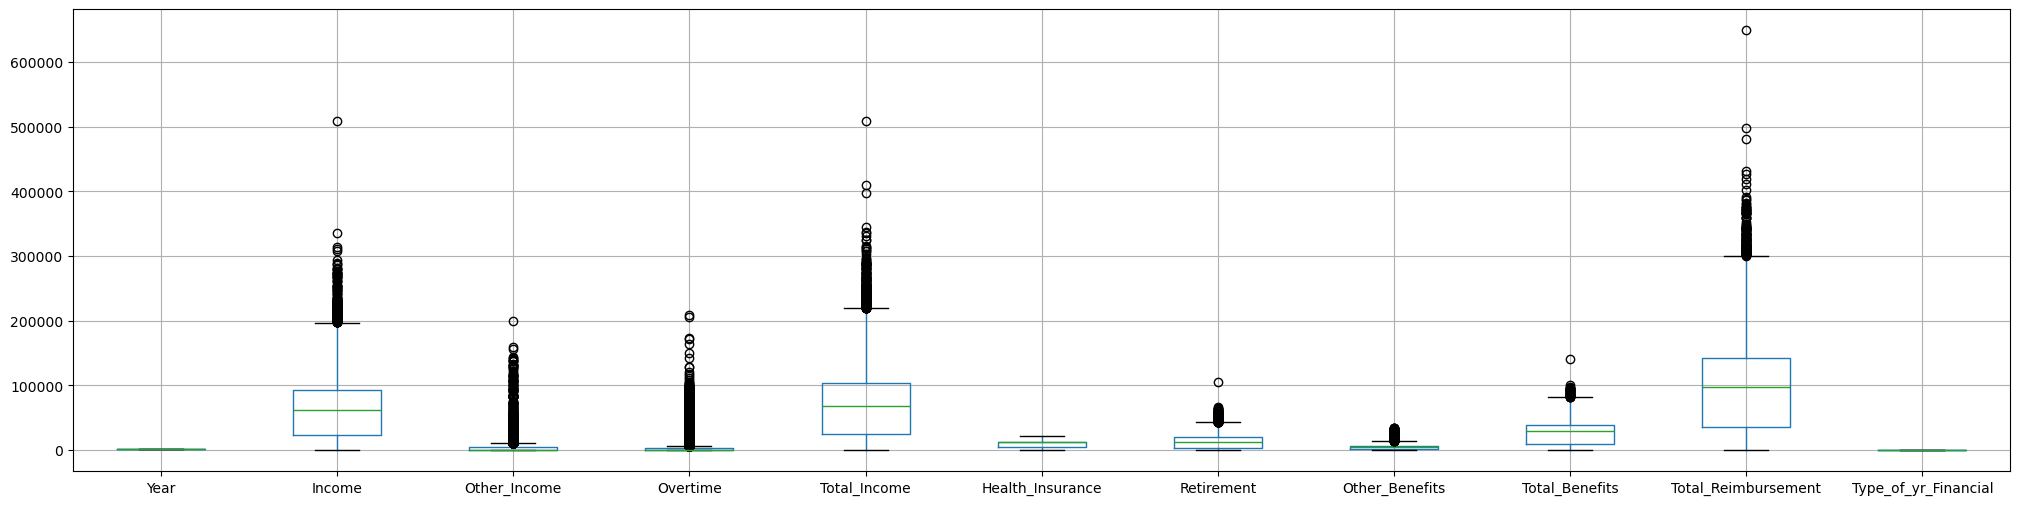

In [13]:
plt.figure(figsize=(25,6))
df.boxplot()

In [14]:
cols = [
    "Income",
    "Other_Income",
    "Overtime",
    "Total_Income",
    "Health_Insurance",
    "Retirement",
    "Other_Benefits",
    "Total_Benefits",
    "Total_Reimbursement"
]

for col in cols:
    
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

<Axes: >

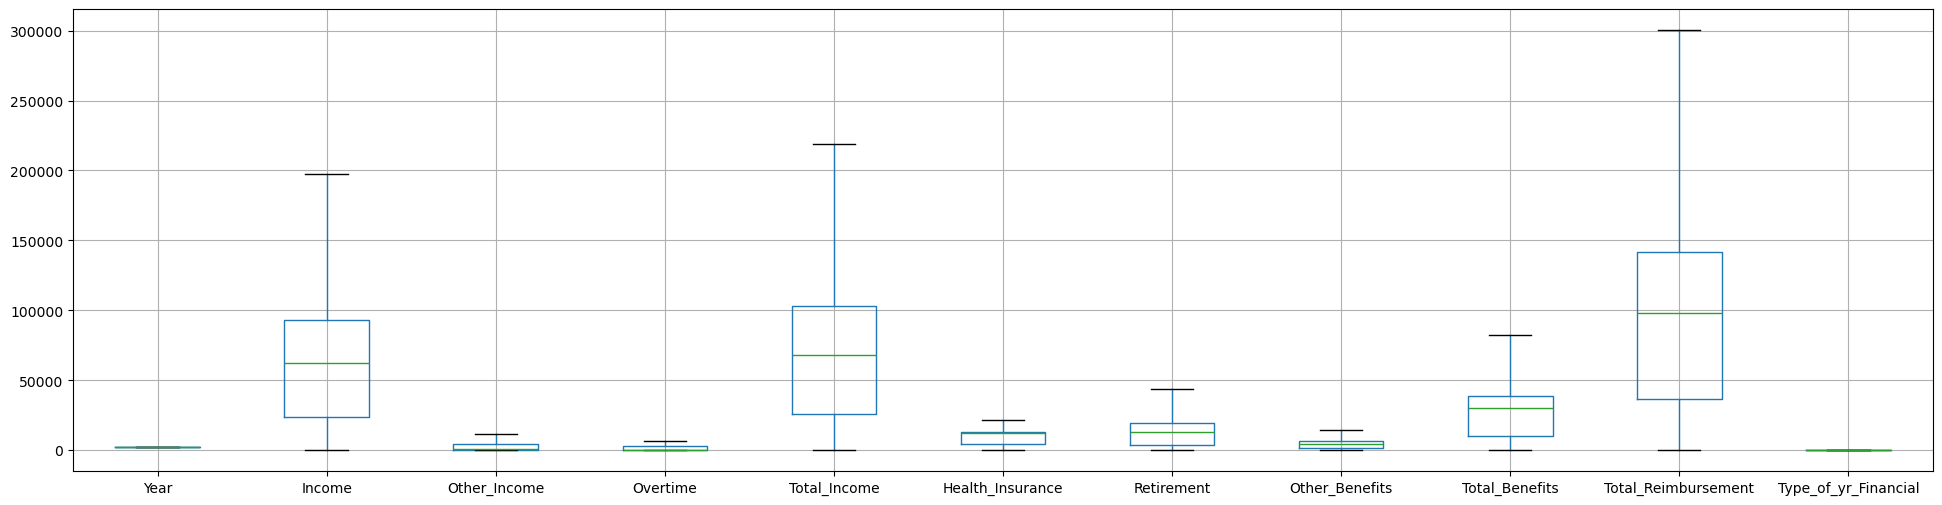

In [15]:
plt.figure(figsize=(24,6))
df.boxplot()

In [16]:
x = df.drop("Total_Reimbursement", axis=1)
y = df["Total_Reimbursement"]

In [17]:
x.columns

Index(['Year', 'Income', 'Other_Income', 'Overtime', 'Total_Income',
       'Health_Insurance', 'Retirement', 'Other_Benefits', 'Total_Benefits',
       'Type_of_yr_Financial'],
      dtype='object')

## Correlation Analysis

<Axes: >

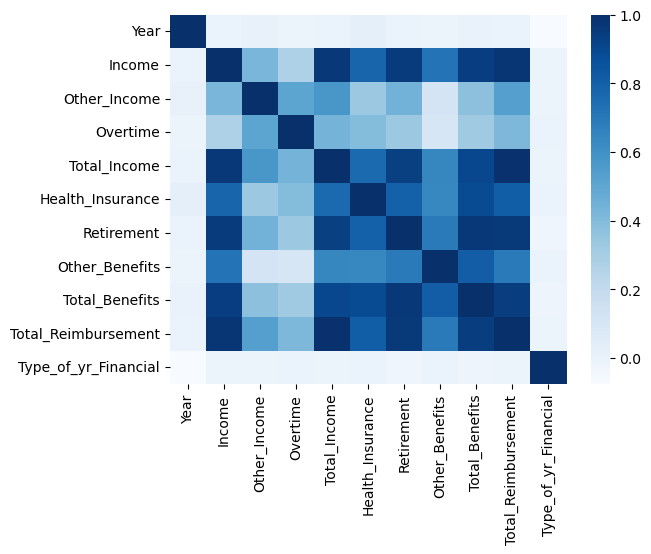

In [18]:
sns.heatmap(df.corr(), cmap="Blues")

In [19]:
y = df["Total_Reimbursement"]
x = df.drop("Total_Reimbursement", axis=1)

## Train Test Split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
x_train.shape, x_test.shape

((39835, 10), (9959, 10))

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
x_train_scaled = (x_train - x_train.mean()) / x_train.std()

x_test_scaled = (x_test - x_train.mean()) / x_train.std()

In [24]:
x_train_scaled.head()

,Year,Income,Other_Income,Overtime,Total_Income,Health_Insurance,Retirement,Other_Benefits,Total_Benefits,Type_of_yr_Financial
45407,1.231909,0.325822,-0.423863,-0.629248,0.147120,0.734543,0.397436,0.558564,0.552747,0.859059
13249,0.386783,0.877162,1.468902,-0.629248,0.763430,0.246684,0.722327,1.390128,0.769187,0.859059
13475,0.386783,-0.687178,-0.722725,-0.629248,-0.745576,-1.037698,-0.610544,-0.592768,-0.783930,-1.164035
35836,-1.303469,0.777321,2.166913,1.936928,1.330621,0.712882,1.577290,-0.649721,0.982214,-1.164035
498,-0.458343,0.591684,2.166913,1.936928,0.848993,0.848051,0.460767,1.309774,0.776532,0.859059


## Correlation Matrix

<Axes: >

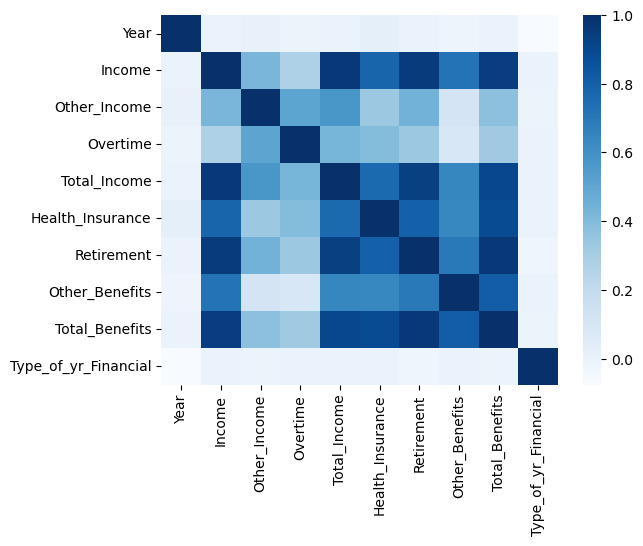

In [25]:
sns.heatmap(x_train_scaled.corr(), cmap="Blues")

## Variance Inflation Factor (VIF)

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [27]:
vif = pd.DataFrame()

vif["Feature"] = x_train_scaled.columns

vif["VIF"] = [
    variance_inflation_factor(
        x_train_scaled.values,
        i
    )
    for i in range(x_train_scaled.shape[1])
]

vif

,Feature,VIF
0,Year,1.011030
1,Income,41.380022
2,Other_Income,2.380213
3,Overtime,2.159459
4,Total_Income,37.901803
5,Health_Insurance,33.724017
6,Retirement,153.464704
7,Other_Benefits,22.576710
8,Total_Benefits,406.901639
9,Type_of_yr_Financial,1.010313


In [28]:
x_train_scaled = x_train_scaled.drop("Total_Benefits", axis=1)
x_test_scaled = x_test_scaled.drop("Total_Benefits", axis=1)

In [29]:
vif = pd.DataFrame()

vif["Feature"] = x_train_scaled.columns

vif["VIF"] = [
    variance_inflation_factor(
        x_train_scaled.values,
        i
    )
    for i in range(x_train_scaled.shape[1])
]

vif

,Feature,VIF
0,Year,1.010466
1,Income,41.379470
2,Other_Income,2.362989
3,Overtime,2.157980
4,Total_Income,37.863006
5,Health_Insurance,3.168236
6,Retirement,12.642585
7,Other_Benefits,2.421804
8,Type_of_yr_Financial,1.010282


### Dropping Total_Income because it is derived from Income, Other_Income and Overtime.

In [30]:
x_train_scaled = x_train_scaled.drop("Total_Income", axis=1)
x_test_scaled = x_test_scaled.drop("Total_Income", axis=1)

In [31]:
vif = pd.DataFrame()

vif["Feature"] = x_train_scaled.columns

vif["VIF"] = [
    variance_inflation_factor(
        x_train_scaled.values,
        i
    )
    for i in range(x_train_scaled.shape[1])
]

vif

,Feature,VIF
0,Year,1.010436
1,Income,12.405368
2,Other_Income,1.658761
3,Overtime,1.562049
4,Health_Insurance,3.147550
5,Retirement,12.603864
6,Other_Benefits,2.404436
7,Type_of_yr_Financial,1.010281


### Income is more important for reimbursement prediction so we would drop Retirement.

In [32]:
x_train_scaled = x_train_scaled.drop("Retirement", axis=1)
x_test_scaled = x_test_scaled.drop("Retirement", axis=1)

In [33]:
vif = pd.DataFrame()

vif["Feature"] = x_train_scaled.columns

vif["VIF"] = [
    variance_inflation_factor(
        x_train_scaled.values,
        i
    )
    for i in range(x_train_scaled.shape[1])
]

vif

,Feature,VIF
0,Year,1.010070
1,Income,3.844431
2,Other_Income,1.648341
3,Overtime,1.533099
4,Health_Insurance,2.992224
5,Other_Benefits,2.396838
6,Type_of_yr_Financial,1.005886


## MLR Full Model

In [34]:
x_train_scaled = sm.add_constant(x_train_scaled)
model_1 = sm.OLS(y_train, x_train_scaled).fit()
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Total_Reimbursement   R-squared:                       0.980
Model:                             OLS   Adj. R-squared:                  0.980
Method:                  Least Squares   F-statistic:                 2.831e+05
Date:                 Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                         19:11:29   Log-Likelihood:            -4.2121e+05
No. Observations:                39835   AIC:                         8.424e+05
Df Residuals:                    39827   BIC:                         8.425e+05
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  9.78e+04     47.404   2063.229      0.000    9.77e+04    9.79e+04
Year                   -26.7243     47.642     -0.561      0.575    -120.104      66.656
Income                5.508e+04     92.947    592.588      0.000    5.49e+04    5.53e+04
Other_Income          7332.0811     60.861    120.472      0.000    7212.792    7451.371
Overtime              7049.7578     58.695    120.108      0.000    6934.714    7164.802
Health_Insurance      4568.8468     82.000     55.718      0.000    4408.125    4729.569
Other_Benefits        2741.5773     73.390     37.356      0.000    2597.731    2885.423
Type_of_yr_Financial  -230.0406     47.544     -4.839      0.000    -323.227    -136.854
==============================================================================
Omnibus:                    33675.472   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1826634.271
Skew:                           3.771   Prob(JB):                         0.00
Kurtosis:                      35.305   Cond. No.                         4.07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Removing Insignificant Variables

In [35]:
x_train_scaled = x_train_scaled.drop("Year", axis=1)
x_test_scaled = x_test_scaled.drop("Year", axis=1)

In [36]:
model_2 = sm.OLS(y_train, x_train_scaled).fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Total_Reimbursement   R-squared:                       0.980
Model:                             OLS   Adj. R-squared:                  0.980
Method:                  Least Squares   F-statistic:                 3.303e+05
Date:                 Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                         19:11:29   Log-Likelihood:            -4.2121e+05
No. Observations:                39835   AIC:                         8.424e+05
Df Residuals:                    39828   BIC:                         8.425e+05
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  9.78e+04     47.403   2063.247      0.000    9.77e+04    9.79e+04
Income                5.508e+04     92.914    592.810      0.000    5.49e+04    5.53e+04
Other_Income          7331.4095     60.849    120.485      0.000    7212.144    7450.675
Overtime              7051.1217     58.644    120.235      0.000    6936.178    7166.066
Health_Insurance      4566.1846     81.862     55.779      0.000    4405.733    4726.636
Other_Benefits        2742.7104     73.362     37.386      0.000    2598.920    2886.501
Type_of_yr_Financial  -228.0291     47.408     -4.810      0.000    -320.949    -135.109
==============================================================================
Omnibus:                    33672.378   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1825949.847
Skew:                           3.770   Prob(JB):                         0.00
Kurtosis:                      35.299   Cond. No.                         4.07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Looks like Year was not contributing meaningful predictive power so removing it simplified the model without hurting performance.

## MLR Model with Interaction Effect

In [37]:
x_train_scaled["Income_Other_Income"] = (
    x_train_scaled["Income"]
    * x_train_scaled["Other_Income"]
)

x_test_scaled["Income_Other_Income"] = (
    x_test_scaled["Income"]
    * x_test_scaled["Other_Income"]
)

In [38]:
model_3 = sm.OLS(y_train, x_train_scaled).fit()

model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Total_Reimbursement   R-squared:                       0.981
Model:                             OLS   Adj. R-squared:                  0.981
Method:                  Least Squares   F-statistic:                 2.881e+05
Date:                 Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                         19:11:29   Log-Likelihood:            -4.2087e+05
No. Observations:                39835   AIC:                         8.417e+05
Df Residuals:                    39827   BIC:                         8.418e+05
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 9.714e+04     53.350   1820.882      0.000     9.7e+04    9.72e+04
Income                 5.43e+04     96.847    560.661      0.000    5.41e+04    5.45e+04
Other_Income          6649.6326     65.710    101.197      0.000    6520.840    6778.425
Overtime              6982.6108     58.205    119.965      0.000    6868.527    7096.695
Health_Insurance      4939.4004     82.409     59.938      0.000    4777.877    5100.924
Other_Benefits        3684.1341     81.137     45.406      0.000    3525.103    3843.165
Type_of_yr_Financial  -230.7245     47.005     -4.908      0.000    -322.856    -138.593
Income_Other_Income   1563.1585     59.690     26.188      0.000    1446.164    1680.153
==============================================================================
Omnibus:                    34638.981   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2098478.297
Skew:                           3.907   Prob(JB):                         0.00
Kurtosis:                      37.688   Cond. No.                         4.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Compare Model Performances
- R² improved from 0.980 → 0.981
- AIC reduced
- interaction term is statistically significant (p < 0.05)

We’ll use model_3 as the final model.

## Linear Relationship between Dependent and Independent Variable

In [39]:
x_test_scaled = sm.add_constant(x_test_scaled)

In [40]:
y_pred = model_3.predict(x_test_scaled)

<Axes: xlabel='Total_Reimbursement', ylabel='None'>

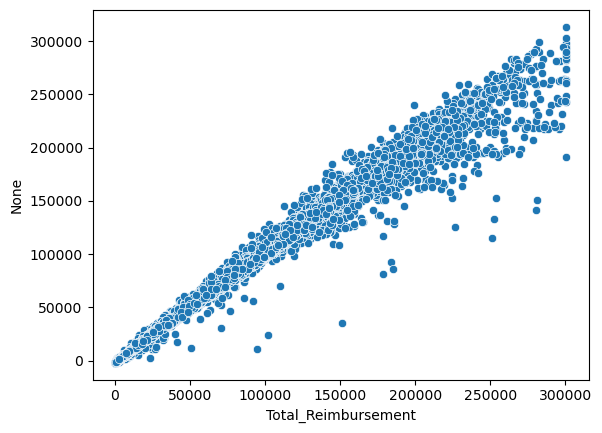

In [41]:
sns.scatterplot(x=y_test, y=y_pred)

## Autocorrelation
The Durbin-Watson statistic is close to 2, indicating no significant autocorrelation in the residuals.

## Heteroskedasticity

In [42]:
residuals = y_test - y_pred

Text(0, 0.5, 'Residuals')

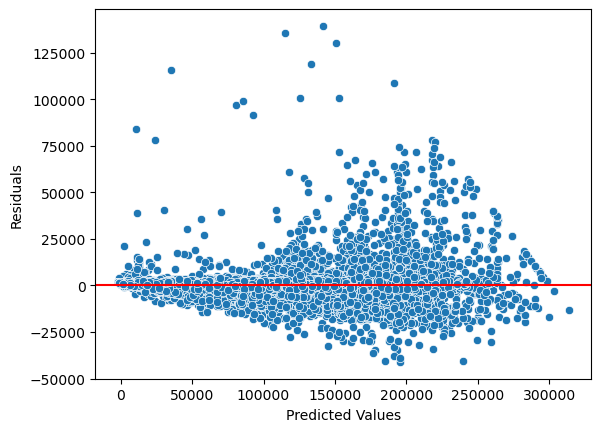

In [43]:
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

Text(0.5, 0, 'Residuals')

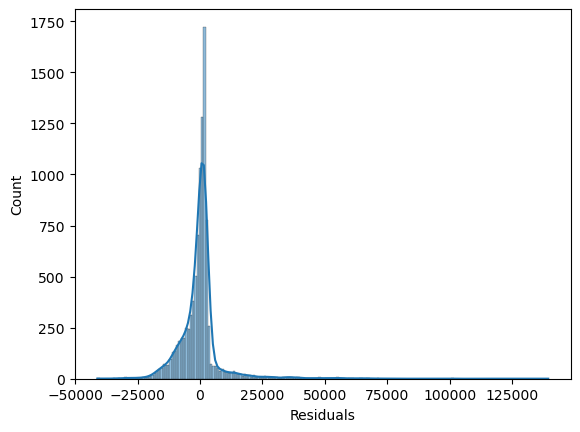

In [44]:
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")

## Model Evaluation

In [45]:
print("R-Squared:", model_3.rsquared)

print("Adjusted R-Squared:", model_3.rsquared_adj)

print("F-Statistic:", model_3.fvalue)

print("Prob (F-Statistic):", model_3.f_pvalue)

R-Squared: 0.9806320033015972
Adjusted R-Squared: 0.9806285991793462
F-Statistic: 288071.9113499033
Prob (F-Statistic): 0.0


In [46]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [47]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

In [48]:
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

MSE: 93871864.77932826
RMSE: 9688.74939191474
MAE: 4919.196743834682
MAPE: 0.25242484820703337


In [49]:
comparison = pd.DataFrame({

    "Model_Name": [
        "model_2",
        "model_3"
    ],

    "R-squared": [
        model_2.rsquared,
        model_3.rsquared
    ],

    "Adj. R-squared": [
        model_2.rsquared_adj,
        model_3.rsquared_adj
    ],

    "MSE": [
        mean_squared_error(
            y_train,
            model_2.predict(
                x_train_scaled.drop("Income_Other_Income", axis=1)
            )
        ),

        mean_squared_error(y_test, y_pred)
    ],

    "RMSE": [

        np.sqrt(
            mean_squared_error(
                y_train,
                model_2.predict(
                    x_train_scaled.drop("Income_Other_Income", axis=1)
                )
            )
        ),

        np.sqrt(mean_squared_error(y_test, y_pred))
    ],

    "MAE": [

        mean_absolute_error(
            y_train,
            model_2.predict(
                x_train_scaled.drop("Income_Other_Income", axis=1)
            )
        ),

        mean_absolute_error(y_test, y_pred)
    ],

    "MAPE": [

        mean_absolute_percentage_error(
            y_train,
            model_2.predict(
                x_train_scaled.drop("Income_Other_Income", axis=1)
            )
        ),

        mean_absolute_percentage_error(y_test, y_pred)
    ]
})

comparison

,Model_Name,R-squared,Adj. R-squared,MSE,RMSE,MAE,MAPE
0,model_2,0.980298,0.980296,8.949633e+07,9460.250172,5023.772437,0.381742
1,model_3,0.980632,0.980629,9.387186e+07,9688.749392,4919.196744,0.252425


## Conclusion

A Multiple Linear Regression model was developed to predict employee reimbursement values using income and benefits-related variables.

Multicollinearity was reduced using VIF analysis, and statistically insignificant variables were removed to improve model interpretability. An interaction effect between Income and Other_Income further improved model performance.

Among the models developed, model_3 achieved the best overall performance with the highest R-squared and lower prediction error metrics.